## Ejercicio 1: Agente de aprobación de crédito





### Ficha PEAS


**P (Medida de desempeño):** Aprobar solicitudes de crédito adecuadas y rechazar las que representen un mayor riesgo.

**E (Entorno):** Sistema de evaluación de solicitudes de crédito.

**A (Actuadores):** Aprobar, aprobar con condición o rechazar la solicitud.

**S (Sensores):** Ingreso mensual, monto solicitado e historial moroso del solicitante.

### Justificación de las reglas


Se utilizará la relación entre el monto solicitado y el ingreso mensual para evaluar el nivel de riesgo de la solicitud.
Si el solicitante tiene historial moroso, la solicitud será rechazada por representar un mayor riesgo.
Si no tiene historial moroso, una relación baja permitirá aprobar el crédito y una relación intermedia permitirá aprobarlo con condición.
Cuando la relación sea demasiado alta, la solicitud será rechazada porque el monto solicitado es elevado respecto a sus ingresos.

### Código


In [1]:
# funcion para evaluar la solicitud
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):

    # calculamos la relacion entre el monto y el ingreso
    relacion = monto_solicitado / ingreso_mensual

    # si tiene historial moroso se rechaza
    if tiene_historial_moroso:
        accion = "Rechazar"
        motivo = "El solicitante tiene historial moroso."

    # si la relacion es hasta 3 se aprueba
    elif relacion <= 3:
        accion = "Aprobar"
        motivo = "El monto solicitado es adecuado respecto al ingreso mensual."

    # si la relacion esta entre 3 y 5 se aprueba con condicion
    elif relacion <= 5:
        accion = "Aprobar con condición"
        motivo = "El monto solicitado es elevado respecto al ingreso mensual."

    # si pasa de 5 se rechaza
    else:
        accion = "Rechazar"
        motivo = "El monto solicitado es demasiado alto respecto al ingreso mensual."

    # devolvemos la accion y el motivo
    return accion, motivo

### Simulación y pruebas


In [2]:
# casos para probar el agente
casos = [
    (2000, 4000, False),   # relacion 2
    (2000, 6000, False),   # relacion 3 limite
    (2000, 8000, False),   # relacion 4
    (2000, 10000, False),  # relacion 5 limite
    (2000, 12000, False),  # relacion 6
    (3000, 4000, True)     # tiene historial moroso
]

# recorremos cada caso y usamos la funcion
for ingreso, monto, moroso in casos:
    accion, motivo = agente_credito(ingreso, monto, moroso)

    print("ingreso:", ingreso)
    print("monto:", monto)
    print("historial moroso:", moroso)
    print("accion:", accion)
    print("motivo:", motivo)
    print("------------------------")

ingreso: 2000
monto: 4000
historial moroso: False
accion: Aprobar
motivo: El monto solicitado es adecuado respecto al ingreso mensual.
------------------------
ingreso: 2000
monto: 6000
historial moroso: False
accion: Aprobar
motivo: El monto solicitado es adecuado respecto al ingreso mensual.
------------------------
ingreso: 2000
monto: 8000
historial moroso: False
accion: Aprobar con condición
motivo: El monto solicitado es elevado respecto al ingreso mensual.
------------------------
ingreso: 2000
monto: 10000
historial moroso: False
accion: Aprobar con condición
motivo: El monto solicitado es elevado respecto al ingreso mensual.
------------------------
ingreso: 2000
monto: 12000
historial moroso: False
accion: Rechazar
motivo: El monto solicitado es demasiado alto respecto al ingreso mensual.
------------------------
ingreso: 3000
monto: 4000
historial moroso: True
accion: Rechazar
motivo: El solicitante tiene historial moroso.
------------------------


### Visualización

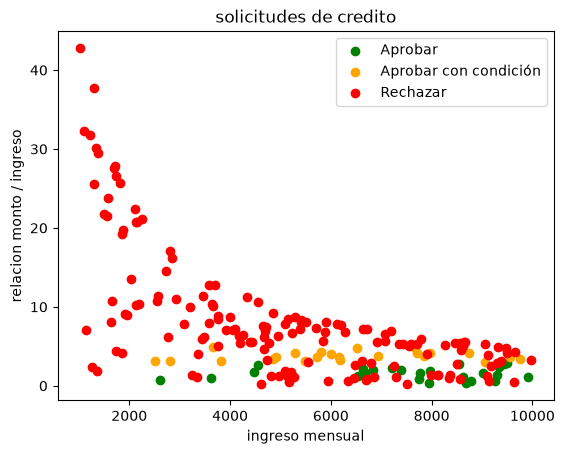

In [3]:
# importamos numpy para generar datos aleatorios
import numpy as np

# importamos matplotlib para hacer el grafico
import matplotlib.pyplot as plt


# creamos listas vacias para guardar los resultados
ingresos = []
relaciones = []
acciones = []


# hacemos 200 solicitudes de credito
for i in range(200):

    # generamos un ingreso mensual aleatorio entre 1000 y 10000
    ingreso = np.random.randint(1000, 10001)

    # generamos un monto solicitado entre 1000 y 50000
    monto = np.random.randint(1000, 50001)

    # elegimos al azar si tiene historial moroso o no
    moroso = np.random.choice([True, False])

    # calculamos la relacion entre el monto y el ingreso
    relacion = monto / ingreso

    # mandamos los datos a nuestro agente para que tome una decision
    accion, motivo = agente_credito(ingreso, monto, moroso)

    # guardamos los resultados en las listas
    ingresos.append(ingreso)
    relaciones.append(relacion)
    acciones.append(accion)


# asignamos un color para cada posible decision
colores = {
    "Aprobar": "green",
    "Aprobar con condición": "orange",
    "Rechazar": "red"
}


# recorremos las tres posibles acciones
for accion in colores:

    # estas listas guardaran los puntos de cada accion
    x = []
    y = []

    # revisamos las 200 solicitudes
    for i in range(200):

        # solo tomamos los datos que pertenecen a esta accion
        if acciones[i] == accion:
            x.append(ingresos[i])
            y.append(relaciones[i])

    # dibujamos los puntos de esta accion
    plt.scatter(x, y, color=colores[accion], label=accion)


# colocamos los nombres de los ejes
plt.xlabel("ingreso mensual")
plt.ylabel("relacion monto / ingreso")

# colocamos el titulo y la leyenda
plt.title("solicitudes de credito")
plt.legend()

# mostramos el grafico
plt.show()